# Fase 1: Construyendo el Multiverso del Jugador (Min. 4 Dimensiones)

Creen un Jupyter Notebook nuevo, carguen el dataset proporcionado en GitHub y seleccionen a su "Jugador Estrella" (puede ser el jugador con más goles o su favorito del dataset, la decisión es suya).

In [1]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/mricardo89/data-mining/main/Unit-III/datasets/players_data-2025_2026.csv"
df = pd.read_csv(url)

print("Jugadores en el dataset", len(df))

Jugadores en el dataset 2839


---
**1. Construyan la matriz multidimensional X seleccionando al menos 4 características numéricas (pueden ser más) continuas (float) que definan el rendimiento del jugador (por ejemplo: Goles, Asistencias, Minutos_Jugados, Precisión_Pases, Recuperaciones, etc.).**

In [2]:
features = ['Min', 'Gls', 'Ast', 'Sh', 'SoT']

X = df[features].astype(float)
X.index = df['Player']

print("Dimensiones de X", X.shape)
X.describe()

Dimensiones de X (2839, 5)


,Min,Gls,Ast,Sh,SoT
count,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000
mean,1218.580134,1.660444,1.159211,15.511800,5.320888
std,963.218994,2.932688,1.833065,18.845159,7.556381
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,320.500000,0.000000,0.000000,2.000000,0.000000
50%,1074.000000,0.000000,0.000000,9.000000,2.000000
75%,1972.500000,2.000000,2.000000,22.000000,7.000000
max,3420.000000,36.000000,21.000000,146.000000,67.000000


---
**2. Creen un vector para su jugador estrella y otro vector para el resto de los candidatos.**

In [3]:
idx_estrella = df['Gls'].idxmax()
estrella = df.loc[idx_estrella, 'Player']

vector_estrella = X.loc[estrella].values
candidatos = X.drop(index=estrella)

print("Jugador estrella", estrella)
print("Su vector", vector_estrella)
print("Candidatos restantes", len(candidatos))

Jugador estrella Harry Kane
Su vector [2377.   36.    5.  119.   67.]
Candidatos restantes 2838


---
**3. Pregunta de control: Antes de medir cualquier distancia, ¿qué operación de la Unidad II deben aplicarle obligatoriamente a estas 4 columnas para que los Minutos_Jugados (rango en miles) no aplasten matemáticamente a los Goles (rango en decenas)? Apliquen esa transformación en el código.**

> **Tu respuesta:** Z-Score, fórmula (X - media) / desviación estándar. Sin ella los minutos dominan la distancia euclidiana y los goles quedan matemáticamente invisibles.

In [4]:
X_z = (X - X.mean()) / X.std()

print(X_z.mean().round(4))
print(X_z.std().round(4))
X_z.head()

Min    0.0
Gls    0.0
Ast   -0.0
Sh     0.0
SoT   -0.0
dtype: float64
Min    1.0
Gls    1.0
Ast    1.0
Sh     1.0
SoT    1.0
dtype: float64


,Min,Gls,Ast,Sh,SoT
Player,,,,,
Brenden Aaronson,1.277404,0.797752,2.095283,1.670891,1.545596
Jerome Abbey,-1.247463,-0.566185,-0.632390,-0.823119,-0.704158
Zach Abbott,-1.094850,-0.566185,-0.632390,-0.823119,-0.704158
Jones El-Abdellaoui,-0.558108,0.115783,-0.632390,0.078970,-0.174804
Himad Abdelli,-1.121843,-0.566185,-0.632390,-0.610862,-0.571820


---
# Fase 2: El Duelo de Distancias (Euclidiana vs. Manhattan)

La distancia euclidiana (la línea recta) no es la única forma de viajar por el espacio vectorial. Existen otras métricas como la Distancia Manhattan (Norma L1), que calcula la distancia moviéndose estrictamente en ángulos rectos, como si un taxi navegara por las cuadras de Nueva York, también es conocida como la distancia del taxista.

---
**1. Investiguen y escriban en su Notebook la fórmula matemática de la Distancia Manhattan.**

$$d_{1}(p, q) = \sum_{i=1}^{n} |p_i - q_i|$$

Contra la Euclidiana, que eleva al cuadrado cada diferencia y saca raíz.

$$d_{2}(p, q) = \sqrt{\sum_{i=1}^{n} (p_i - q_i)^2}$$

---
**2. Programen una celda para encontrar al jugador más similar a su estrella usando la Distancia Euclidiana. Impriman el nombre del reemplazo sugerido.**

In [5]:
vector_estrella_z = X_z.loc[estrella]
candidatos_z = X_z.drop(index=estrella)

dist_euclidiana = np.linalg.norm(candidatos_z - vector_estrella_z, axis=1)

print("Reemplazo sugerido (Euclidiana)", candidatos_z.index[dist_euclidiana.argmin()])

Reemplazo sugerido (Euclidiana) Erling Haaland


---
**3. En la siguiente celda, busquen al reemplazo calculando la Distancia Manhattan (deberán generar una función custom para calcular esta distancia).**

In [6]:
def distancia_manhattan(a, b):
    return np.abs(a - b).sum()

dist_manhattan = candidatos_z.apply(lambda fila: distancia_manhattan(fila, vector_estrella_z), axis=1)

print("Reemplazo sugerido (Manhattan)", dist_manhattan.idxmin())

Reemplazo sugerido (Manhattan) Kylian Mbappé


---
**4. Análisis Crítico: ¿El algoritmo sugirió al mismo jugador en ambos casos? Como ingenieros, expliquen en un bloque de Markdown las diferencias observables entre la Distancia Euclidiana comparado con la Distancia Manhattan.**

> **Tu respuesta:** No. La Euclidiana sugiere a Erling Haaland y la Manhattan a Kylian Mbappé.
> 
> Mbappé suma menos diferencia total (5.94 contra 6.73) pero casi toda en goles. La Euclidiana eleva al cuadrado y castiga ese hueco, la Manhattan solo suma absolutos y no lo penaliza.
> 
> La distancia Euclidiana busca un perfil parejo sin debilidades graves y la Manhattan tolera una debilidad puntual si el resto de las métricas están cerca.

---
# Fase 3: El Reto de Visualización en 4D (Investigación Independiente)

El director técnico quiere ver un reporte visual de por qué el jugador que sugirieron es el más parecido al original.

El problema físico es que ustedes seleccionaron 4 (o más) características. Los seres humanos solo podemos ver un eje X, un eje Y y un eje Z.

---
**1. Investiguen y elijan una técnica o librería en Python que les permita proyectar visualmente vectores de 4 dimensiones o más en una pantalla 2D.**

> **Respuesta:** Gráfico de Radar con matplotlib.
>
> Para la gráfica escalamos con Min-Max en lugar de Z-Score, porque el radio de un polar no admite valores negativos.

---
**2. Implementen el código para visualizar a su "Jugador Estrella" junto al "Reemplazo Sugerido" y a un "Tercer Jugador Aleatorio" (para ver el contraste).**

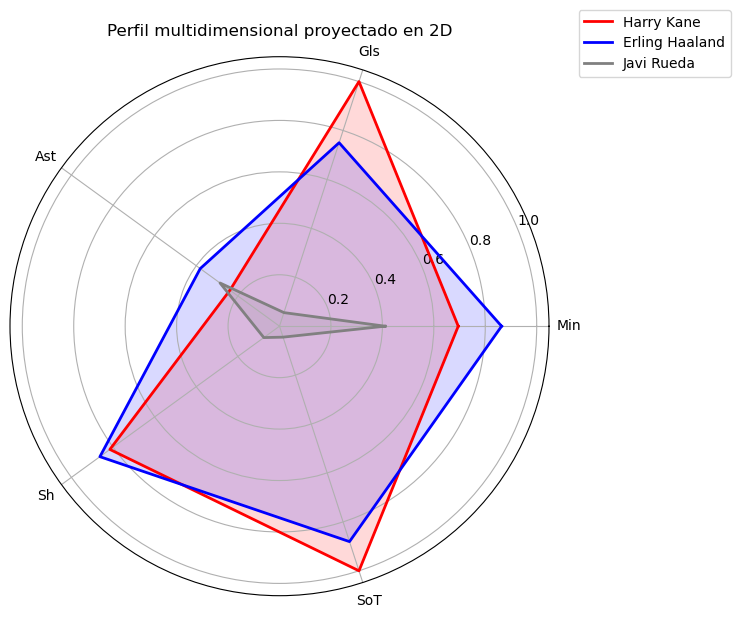

In [7]:
import matplotlib.pyplot as plt

X_radar = (X - X.min()) / (X.max() - X.min())

reemplazo = candidatos_z.index[dist_euclidiana.argmin()]
aleatorio = X[X['Min'] > 900].drop(index=[estrella, reemplazo]).sample(1, random_state=42).index[0]

angulos = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
angulos += angulos[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'polar': True})

for jugador, color in [(estrella, 'red'), (reemplazo, 'blue'), (aleatorio, 'gray')]:
    valores = X_radar.loc[jugador].tolist()
    valores += valores[:1]
    ax.plot(angulos, valores, color=color, linewidth=2, label=jugador)
    ax.fill(angulos, valores, color=color, alpha=0.15)

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(features)
ax.set_title('Perfil multidimensional proyectado en 2D')
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.show()

Kane y Haaland dibujan casi el mismo polígono, solo se separan en goles. Javi Rueda colapsa hacia el centro en las cuatro métricas ofensivas.

---
**3. Entreguen el Notebook documentado comprobando visualmente que los vectores de su estrella y su clon están, efectivamente, muy cerca en el hiperespacio.**